In [1]:
"""
demo_epoch_sampling.py
----------------------

Goal
----
- Build a batched Camera with C poses.
- For each epoch:
    * sample K unique pixel-rays per pose (without replacement),
    * jitter N points along each ray (stratified),
    * return tensors you can feed to a NeRF model later.

Shapes
------
Let C=cameras, K=rays/pose, N=samples/ray.
- rays_o: (C, K, 3)   world-space ray origins
- rays_d: (C, K, 3)   world-space ray directions (unit)
- t_vals: (C, K, N)   parametric distances along each ray
- deltas: (C, K, N)   segment lengths (Δt)
- pts   : (C, K, N, 3) world-space points (rays_o + t_vals * rays_d)

Notes
-----
- Different epochs -> different random subsets because we seed the RNG with
  `base_seed + epoch` (and we *don’t* use deterministic sampling).
- Reproducibility: same base_seed yields the same overall sequence across runs.
- The Camera caches full-grid rays; we use its fast sub-sampling path.
"""

from __future__ import annotations
from dataclasses import dataclass
from typing import Iterator, Optional

import torch

from nerflab.camera.camera import Camera
from nerflab.camera.presets import make_spherical_poses
from nerflab.camera.intrinsics import Intrinsics


@dataclass(frozen=True)
class SamplerConfig:
    # Camera & image
    C: int = 8                   # number of camera poses
    W: int = 64                  # image width  (pixels)
    H: int = 48                  # image height (pixels)
    fx: float = 64.0             # focal lengths (pixels)
    fy: float = 48.0
    # Ray sampling
    K: int = 256                 # rays per camera per epoch (unique on step-grid)
    step: int = 2                # stride for the pixel lattice used to sample K
    # Along-ray sampling
    N: int = 32                  # samples per ray
    t_near: float = 0.2
    t_far: float = 2.5
    # Training loop
    epochs: int = 5
    base_seed: int = 2025        # reproducibility anchor
    # Device / precision
    device: str = "cpu"          # e.g., "cuda" if available
    dtype: torch.dtype = torch.float32


class EpochSampler:
    """
    Wraps a batched Camera and yields per-epoch random ray/point samples.

    Usage
    -----
    cfg = SamplerConfig(C=8, K=512, N=64, epochs=100, device="cuda")
    es = EpochSampler(cfg)
    for epoch, batch in enumerate(es):
        rays_o, rays_d = batch["rays_o"], batch["rays_d"]         # (C,K,3), (C,K,3)
        t_vals, deltas, pts = batch["t_vals"], batch["deltas"], batch["pts"]
        # ... feed (pts, rays_d) to NeRF, compute colors/densities, etc.
    """

    def __init__(self, cfg: SamplerConfig):
        self.cfg = cfg
        self.device = torch.device(cfg.device)

        # 1) Build C camera-to-world poses on a sphere (all look at origin).
        H_wc = make_spherical_poses(
            c=cfg.C, radius=3.0, method="fibonacci", device=self.device, dtype=cfg.dtype
        )  # (C, 4, 4)

        # 2) Intrinsics (principal point is handled inside Intrinsics).
        intr = Intrinsics(
            fx=float(cfg.fx), fy=float(cfg.fy), width=int(cfg.W), height=int(cfg.H)
        )

        # 3) Camera (batched)
        self.cam = Camera(
            H_wc, intr=intr,
            t_bounds=(float(cfg.t_near), float(cfg.t_far)),
            n_points_per_ray=int(cfg.N),
            dtype=cfg.dtype,
        ).to(self.device, cfg.dtype)

        # Small sanity: ensure the lattice is large enough to draw K sites
        H, W, step = cfg.H, cfg.W, cfg.step
        R_full = ((H + step - 1) // step) * ((W + step - 1) // step)
        if cfg.K > R_full:
            raise ValueError(
                f"K={cfg.K} exceeds step-grid capacity {R_full} for H={H}, W={W}, step={step}."
            )

    def __iter__(self) -> Iterator[dict[str, torch.Tensor]]:
        """
        Yields one dict per epoch with:
            - "rays_o": (C,K,3)
            - "rays_d": (C,K,3)
            - "t_vals": (C,K,N)
            - "deltas": (C,K,N)
            - "pts":    (C,K,N,3)
            - "epoch":  (int)
        """
        for epoch in range(self.cfg.epochs):
            # Epoch-specific RNG → different subsets each time, reproducible across runs.
            rng = torch.Generator(device=self.device).manual_seed(self.cfg.base_seed + epoch)

            # K unique pixel sites per camera on the step-strided grid.
            rays_o, rays_d = self.cam.get_rays_sampled(
                rays_per_pose=self.cfg.K,
                step=self.cfg.step,
                frame="world",
                rng=rng,                    # drives WHICH pixels are chosen
                normalize=True,
            )  # (C,K,3) each

            # Stratified samples *along* each selected ray (randomized unless deterministic=True).
            t_vals, deltas, pts = self.cam.sample_along_rays(
                rays_o, rays_d, rng=rng, deterministic=False
            )  # (C,K,N), (C,K,N), (C,K,N,3)

            yield {
                "epoch": epoch,
                "rays_o": rays_o, "rays_d": rays_d,
                "t_vals": t_vals, "deltas": deltas, "pts": pts,
            }

    # Handy utilities for flattening to (B, …) style training batches
    def flatten_for_training(
        self,
        batch: dict[str, torch.Tensor],
        *,
        merge_cameras: bool = True,
    ) -> dict[str, torch.Tensor]:
        """
        Convert (C,K,…) → (C*K, …) (and optionally merge cameras).
        Useful to feed a single big batch into a NeRF MLP.

        Returns keys:
          - rays_o: (C*K, 3)
          - rays_d: (C*K, 3)
          - t_vals: (C*K, N)
          - deltas: (C*K, N)
          - pts   : (C*K, N, 3)
        """
        rays_o = batch["rays_o"].reshape(-1, 3)
        rays_d = batch["rays_d"].reshape(-1, 3)
        t_vals = batch["t_vals"].reshape(-1, self.cfg.N)
        deltas = batch["deltas"].reshape(-1, self.cfg.N)
        pts    = batch["pts"].reshape(-1, self.cfg.N, 3)
        return dict(rays_o=rays_o, rays_d=rays_d, t_vals=t_vals, deltas=deltas, pts=pts)


# --------------------------------------- Demo --------------------------------------- #

if __name__ == "__main__":
    cfg = SamplerConfig(
        C=6, W=64, H=48, fx=64.0, fy=48.0,
        K=256, step=2,
        N=32, t_near=0.2, t_far=2.5,
        epochs=3, base_seed=1337,
        device="cpu",  # set to "cuda" if you have a GPU
        dtype=torch.float32,
    )
    sampler = EpochSampler(cfg)

    for batch in sampler:
        e = batch["epoch"]
        ro, rd, tv, dl, P = batch["rays_o"], batch["rays_d"], batch["t_vals"], batch["deltas"], batch["pts"]
        print(f"[epoch {e}] rays_o:{tuple(ro.shape)} rays_d:{tuple(rd.shape)} "
              f"t_vals:{tuple(tv.shape)} deltas:{tuple(dl.shape)} pts:{tuple(P.shape)}")

        # Example: flatten to (C*K, …) before feeding NeRF
        flat = sampler.flatten_for_training(batch)
        print("  flattened rays:", tuple(flat["rays_o"].shape), tuple(flat["pts"].shape))

        # If you want to break after first epoch in a quick smoke test:
        # break


[epoch 0] rays_o:(6, 256, 3) rays_d:(6, 256, 3) t_vals:(6, 256, 32) deltas:(6, 256, 32) pts:(6, 256, 32, 3)
  flattened rays: (1536, 3) (1536, 32, 3)
[epoch 1] rays_o:(6, 256, 3) rays_d:(6, 256, 3) t_vals:(6, 256, 32) deltas:(6, 256, 32) pts:(6, 256, 32, 3)
  flattened rays: (1536, 3) (1536, 32, 3)
[epoch 2] rays_o:(6, 256, 3) rays_d:(6, 256, 3) t_vals:(6, 256, 32) deltas:(6, 256, 32) pts:(6, 256, 32, 3)
  flattened rays: (1536, 3) (1536, 32, 3)


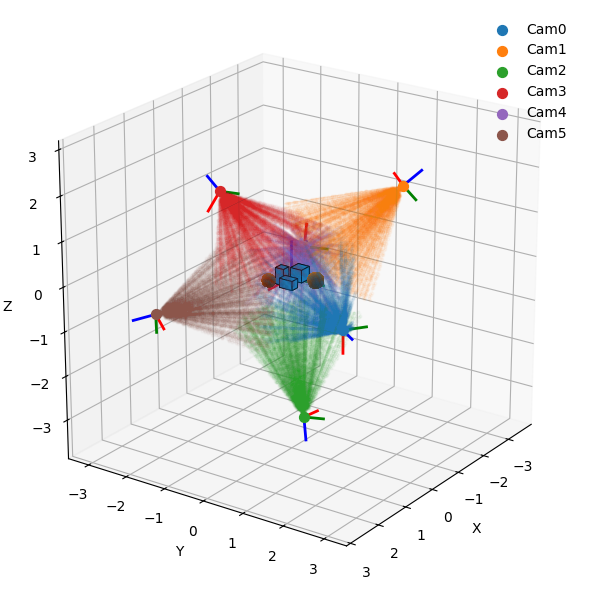

In [12]:
from nerflab import (
     plot_world, load_world, 
)
world = load_world("../data/world.json")
plot_world(
    world,
    cameras=sampler.cam,
    cam_indices="all",
    draw_rays=True, ray_mode="lines", rays_per_pose=cfg.K,
    draw_samples=True, samples_deterministic=False, ray_alpha=0.04, samples_alpha=0.03, shape_edge_alpha=1, shape_face_alpha= 1, set_labels=True, 
)